<!-- Codex test: first cell touched -->
This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [ ]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-12-08 12:10:20.284786: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 12:10:20.288115: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [ ]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-12-08 12:15:25,439 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:40947' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-566e57a7ad5ea8747dcee124f50077e5', 'lambda-45a47e4d8b8686acf1801fe583059152', 'lambda-8b55e38689264840032f7be4c7e898f8', 'lambda-2557559439406e2a032145d87bf6c4b7', 'lambda-0f382cc9cfd6c841088a20b645ae69b4', 'lambda-145a01802de0b53398456122f2e6a1ee', 'lambda-9a9ac8e5c90acedbbbe86edb0830da58', 'lambda-9cbe4e61645624e75a6ac7e5cfd82ea5', 'lambda-f3b467e3b7cc1bdfbefd5c784b0bb677', 'lambda-8069839dfe475a9d423d3c9d09c07f73', 'lambda-7bdf430e61f9e1b8bcb99e21e074a3d0', 'lambda-85c907866f923a82d8c3d8f9df8c6f9e', 'lambda-096083d35492315d94dbfe07cb7ab766', 'lambda-5bbd548b4e289064fa4e16663cc1f23c', 'lambda-eac4b7b1f414c39a64914e7d7f26e2bc', 'lambda-4bd1024699f397d16ea3a2cf54cf17f5', 'lambda-94141714be1d7b4461c94353206fd217', 'lambda-4bb09d9454f4675f115404a34fade1d4', 'lambda-5d74a86da78dca56c5584024424a

Load shendure ortho object.

In [2]:
path="/home/mcn26/project_pi_skr2/shared/tabula_data/shendure"
name="ortho_primordial_v4"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [3]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

scMPRAforge: INFO: Computed a total of 414.7088384600356 estimated collision events, out of a total of 781874.70883846, or 0.05304031883524153%


Let's make some plots showing why we chose nb:

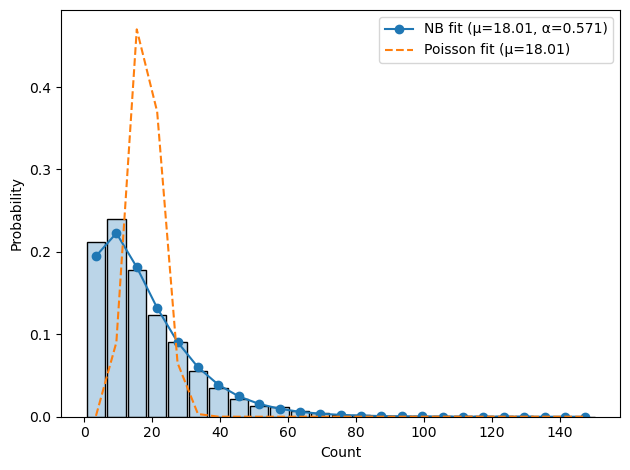

In [4]:
shendure_bounds.transfection_model.plot()

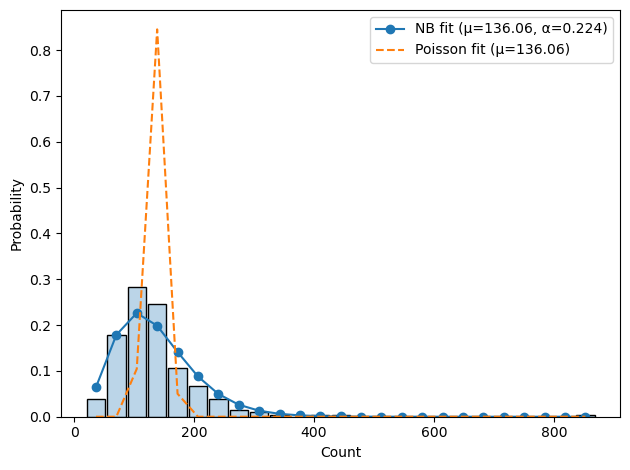

In [5]:
shendure_bounds.library_model.plot()

Now let's save the object:

In [6]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [7]:
cluster.close()
client.close()